# GBIF true-earthworm image dataset audit

This notebook audits the user-approved earthworm scope (`Crassiclitellata` and
`Moniligastrida`) after requiring a GBIF genus key. It uses every distinct
still image attached to each occurrence. White worms, aquatic oligochaetes,
branchiobdellids, and leeches are outside scope.

The notebook prefers the curated manifest, then the downloaded manifest, then
the raw media manifest. GBIF identifications are occurrence metadata, not
independently verified image labels. Re-run all cells after each acquisition or
curation update; do not interpret an unexecuted notebook as dataset results.


In [21]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import yaml

CONFIG_PATH = Path('../configs/gbif_oligochaeta.yaml')
with CONFIG_PATH.open() as handle:
    config = yaml.safe_load(handle)

workspace = {key: Path('..') / value for key, value in config['workspace'].items()}
candidates = [workspace['curated_manifest'], workspace['downloaded_manifest'], workspace['manifest']]
MANIFEST_PATH = next((path for path in candidates if path.is_file()), None)
if MANIFEST_PATH is None:
    raise FileNotFoundError('No GBIF manifest exists yet. Run acquisition/build-manifest first.')

df = pd.read_csv(MANIFEST_PATH, low_memory=False)
print(f'Manifest: {MANIFEST_PATH}')
print(f'Rows (distinct occurrence-image pairs): {len(df):,}')
df.head()


Manifest: ../gbif_oligochaeta/curation/curated_manifest.csv
Rows (distinct occurrence-image pairs): 29,948


,image_id,embedding_row,gbif_id,occurrence_id,dataset_key,basis_of_record,dataset_name,publisher,publishing_org_key,institution_code,...,content_type,bytes,error,exact_duplicate_of,projection_x,projection_y,cluster,cluster_probability,curation_label,curation_notes
0,19a26dbc392393cdf24f5669,0,1024178180,http://www.inaturalist.org/observations/222373,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,1680275,NaN,NaN,1.766455,9.656816,-1,0.0,keep,NaN
1,e00e2738a84dbf6f6fc02d8c,1,1024178180,http://www.inaturalist.org/observations/222373,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,1703301,NaN,NaN,1.568284,9.576187,18,1.0,keep,NaN
2,62b27d4c5537c9d45813f332,2,1038330408,http://naturewatch.org.nz/observations/417744,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,541287,NaN,NaN,1.249657,15.768840,-1,0.0,keep,NaN
3,b62bc52f9087700d63bc2023,3,1038330408,http://naturewatch.org.nz/observations/417744,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,776436,NaN,NaN,-1.937617,8.357933,-1,0.0,keep,NaN
4,b0771e5d9ec454d940c45d4e,4,1098895211,http://www.inaturalist.org/observations/1304158,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,1232698,NaN,NaN,-1.727300,13.842949,-1,0.0,keep,NaN


## 1. Scope, completeness, and label coverage

In [22]:
def nunique(column):
    return int(df[column].nunique(dropna=True)) if column in df else None

overview = pd.Series({
    'image rows': len(df),
    'GBIF occurrences': nunique('gbif_id'),
    'orders': nunique('order_key'),
    'families': nunique('family_key'),
    'genera': nunique('genus_key'),
    'species-labelled rows': int(df.get('species_key', pd.Series(dtype=object)).notna().sum()),
    'unique species keys': nunique('species_key'),
    'datasets': nunique('dataset_key'),
})
display(overview.to_frame('value'))

assert df['genus'].notna().all() and df['genus_key'].notna().all(), 'Genus-defined contract violated'
expected_orders = {str(item['key']) for item in config['gbif']['included_orders']}
observed_orders = set(df['order_key'].dropna().astype(str))
assert observed_orders <= expected_orders, f'Out-of-scope order keys: {observed_orders - expected_orders}'

if 'download_status' in df:
    display(df['download_status'].value_counts(dropna=False).to_frame('images'))
    per_occurrence_status = df.groupby('gbif_id')['download_status'].agg(
        images='size', downloaded=lambda values: (values == 'downloaded').sum())
    per_occurrence_status['complete'] = per_occurrence_status['images'] == per_occurrence_status['downloaded']
    display(per_occurrence_status['complete'].value_counts().rename(index={True: 'complete', False: 'incomplete'}).to_frame('occurrences'))


,value
image rows,29948
GBIF occurrences,10334
orders,2
families,12
genera,73
species-labelled rows,29040
unique species keys,166
datasets,1


,images
download_status,
downloaded,29948


,occurrences
complete,
complete,10334


## 2. Multiple images per occurrence

,images
count,10334.000000
mean,2.898007
std,2.620308
min,1.000000
50%,2.000000
75%,4.000000
90%,6.000000
95%,8.000000
99%,13.000000
max,31.000000


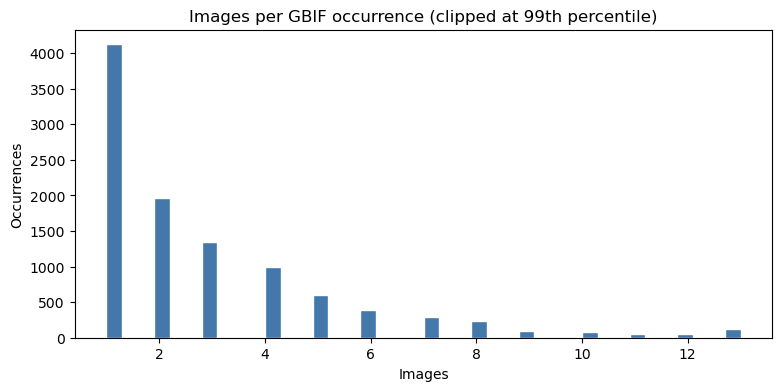

,images
gbif_id,
2619905432,31
6163185183,27
6178976994,24
6130725983,24
5938562642,24
5892992725,20
5892561382,20
5892467994,20
6188091117,20


In [23]:
images_per_occurrence = df.groupby('gbif_id').size().rename('images')
display(images_per_occurrence.describe(percentiles=[.5, .75, .9, .95, .99]).to_frame())
ax = images_per_occurrence.clip(upper=images_per_occurrence.quantile(.99)).plot.hist(
    bins=40, figsize=(9, 4), color='#4477AA', edgecolor='white')
ax.set(title='Images per GBIF occurrence (clipped at 99th percentile)', xlabel='Images', ylabel='Occurrences')
plt.show()
display(images_per_occurrence.sort_values(ascending=False).head(20).to_frame())


## 3. Taxonomic distributions

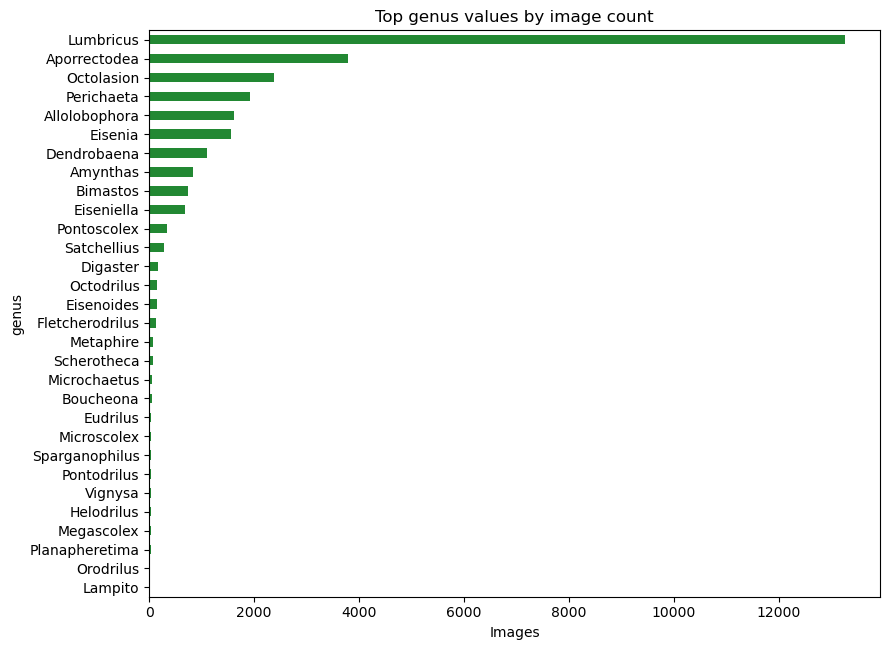

,images
genus,
Lumbricus,13261
Aporrectodea,3791
Octolasion,2370
Perichaeta,1925
Allolobophora,1617
Eisenia,1559
Dendrobaena,1096
Amynthas,837
Bimastos,738


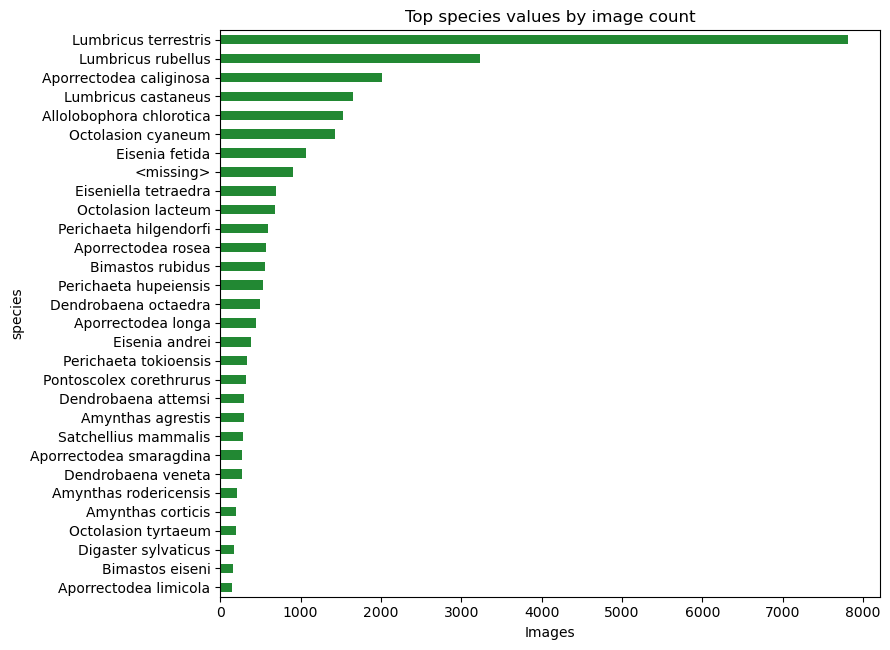

,images
species,
Lumbricus terrestris,7815
Lumbricus rubellus,3234
Aporrectodea caliginosa,2016
Lumbricus castaneus,1650
Allolobophora chlorotica,1527
Octolasion cyaneum,1428
Eisenia fetida,1063
<missing>,908
Eiseniella tetraedra,690


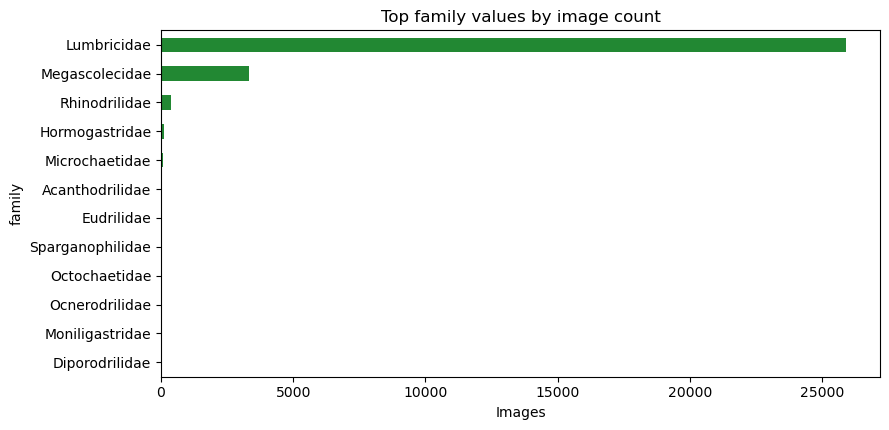

,images
family,
Lumbricidae,25901
Megascolecidae,3315
Rhinodrilidae,378
Hormogastridae,110
Microchaetidae,60
Acanthodrilidae,50
Eudrilidae,40
Sparganophilidae,37
Octochaetidae,33


In [24]:
def top_distribution(column, n=30):
    counts = df[column].fillna('<missing>').value_counts().head(n).sort_values()
    ax = counts.plot.barh(figsize=(9, max(3, n * .22)), color='#228833')
    ax.set(title=f'Top {column} values by image count', xlabel='Images', ylabel=column)
    plt.tight_layout(); plt.show()
    return counts.sort_values(ascending=False).to_frame('images')

display(top_distribution('genus', 30))
display(top_distribution('species', 30))
display(top_distribution('family', 20))


## 4. Geographic and temporal coverage

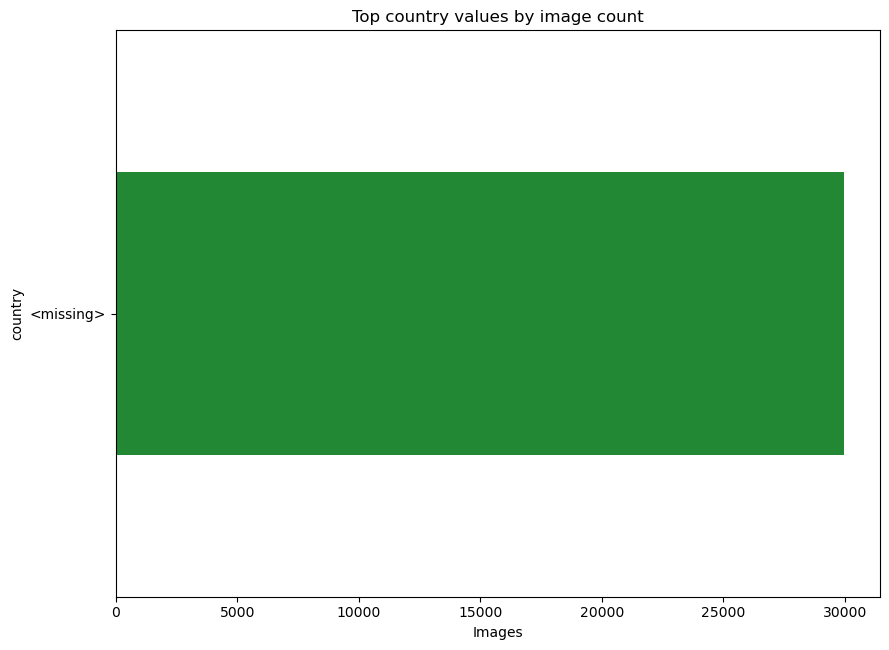

,images
country,
<missing>,29948


Georeferenced occurrences: 10,316


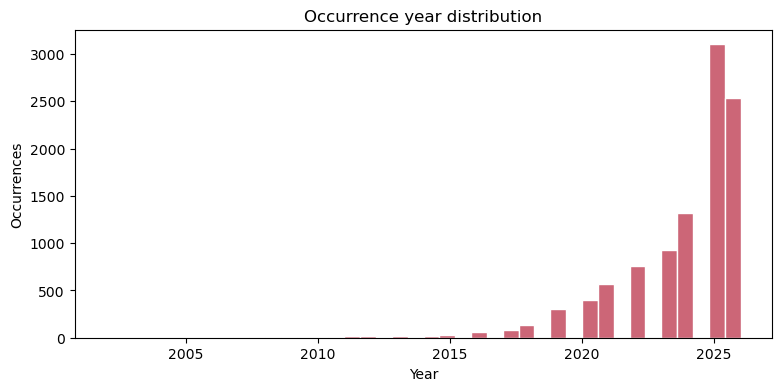

In [25]:
if 'country' in df:
    display(top_distribution('country', 30))

if {'decimal_latitude', 'decimal_longitude'} <= set(df):
    geo = df.drop_duplicates('gbif_id').copy()
    geo['decimal_latitude'] = pd.to_numeric(geo['decimal_latitude'], errors='coerce')
    geo['decimal_longitude'] = pd.to_numeric(geo['decimal_longitude'], errors='coerce')
    geo = geo.dropna(subset=['decimal_latitude', 'decimal_longitude'])
    print(f'Georeferenced occurrences: {len(geo):,}')
    if len(geo):
        fig = px.scatter_geo(geo, lat='decimal_latitude', lon='decimal_longitude',
                             color='genus', hover_name='scientific_name', opacity=.45,
                             title='Georeferenced GBIF earthworm occurrences')
        fig.show()

if 'year' in df:
    years = pd.to_numeric(df.drop_duplicates('gbif_id')['year'], errors='coerce').dropna()
    years = years[(years >= 1700) & (years <= pd.Timestamp.now().year)]
    ax = years.plot.hist(bins=40, figsize=(9, 4), color='#CC6677', edgecolor='white')
    ax.set(title='Occurrence year distribution', xlabel='Year', ylabel='Occurrences'); plt.show()


## 5. Data sources, record types, and licences

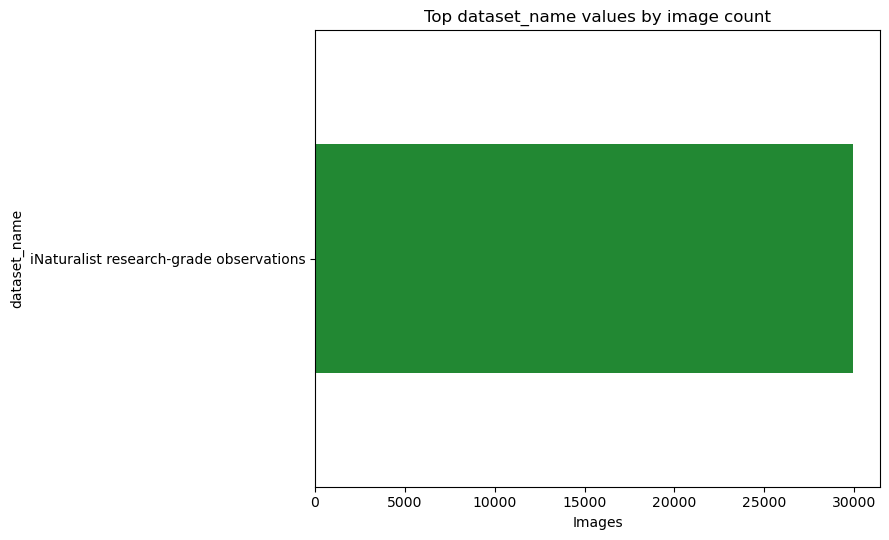

,images
dataset_name,
iNaturalist research-grade observations,29948


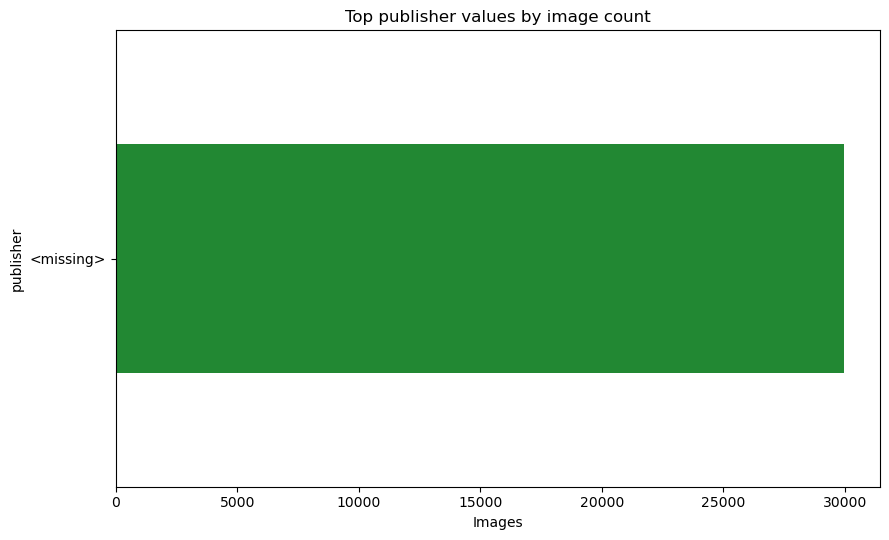

,images
publisher,
<missing>,29948


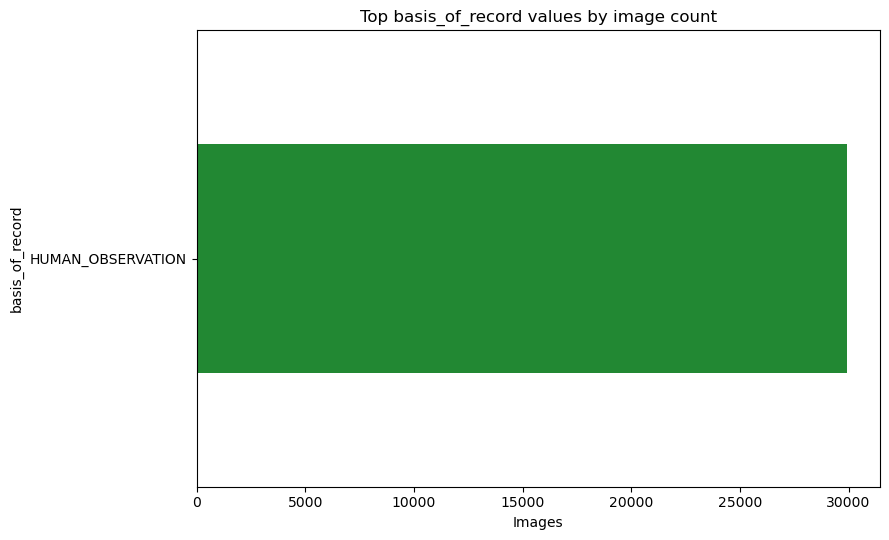

,images
basis_of_record,
HUMAN_OBSERVATION,29948


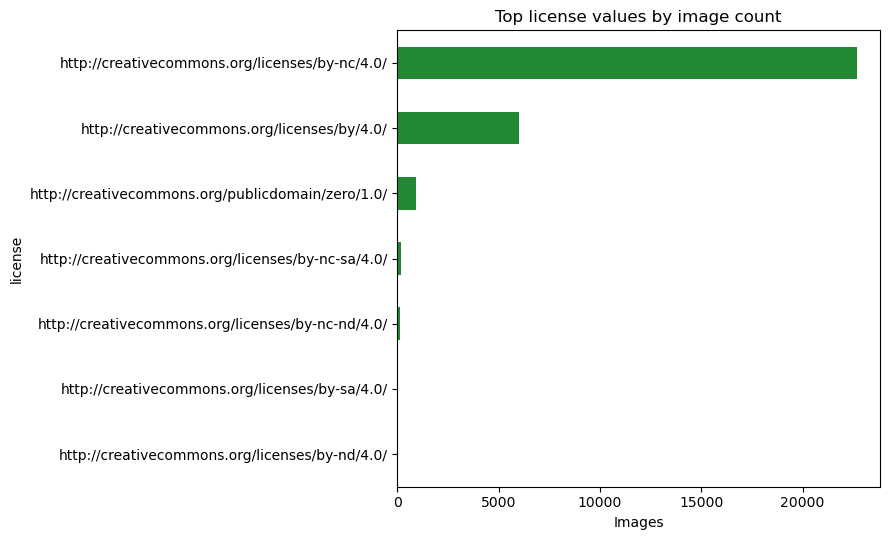

,images
license,
http://creativecommons.org/licenses/by-nc/4.0/,22682
http://creativecommons.org/licenses/by/4.0/,5999
http://creativecommons.org/publicdomain/zero/1.0/,908
http://creativecommons.org/licenses/by-nc-sa/4.0/,185
http://creativecommons.org/licenses/by-nc-nd/4.0/,126
http://creativecommons.org/licenses/by-sa/4.0/,44
http://creativecommons.org/licenses/by-nd/4.0/,4


In [26]:
for column in ['dataset_name', 'publisher', 'basis_of_record', 'license']:
    if column in df:
        display(top_distribution(column, 25))


## 6. Image files, dimensions, and duplicates

In [31]:
for column in ['bytes', 'width', 'height']:
    if column in df:
        df[column] = pd.to_numeric(df[column], errors='coerce')
if {'width', 'height'} <= set(df):
    display(df[['width', 'height', 'bytes']].describe(percentiles=[.01, .1, .5, .9, .99]))
    fig = px.scatter(df.dropna(subset=['width', 'height']), x='width', y='height',
                     color='curation_label' if 'curation_label' in df else None,
                     log_x=True, log_y=True, opacity=.35, title='Downloaded image dimensions',render_mode="svg")
    fig.show()
if 'sha256' in df:
    valid_hash = df['sha256'].dropna().astype(str)
    duplicates = valid_hash.value_counts()
    print(f'Exact duplicate hashes: {(duplicates > 1).sum():,}; duplicate image rows: {(duplicates - 1).clip(lower=0).sum():,}')
    display(df[df['sha256'].isin(duplicates[duplicates > 1].index)].sort_values('sha256').head(100))


,width,height,bytes
count,29948.000000,29948.000000,2.994800e+04
mean,1716.191231,1734.906972,1.577028e+06
std,321.155206,358.016624,9.781406e+05
min,75.000000,75.000000,2.379000e+03
1%,810.470000,739.470000,1.632547e+05
10%,1418.700000,1268.000000,5.222571e+05
50%,1536.000000,2048.000000,1.409566e+06
90%,2048.000000,2048.000000,2.911437e+06
99%,2048.000000,2048.000000,4.463198e+06
max,2048.000000,2048.000000,1.477968e+07


Exact duplicate hashes: 45; duplicate image rows: 45


,image_id,embedding_row,gbif_id,occurrence_id,dataset_key,basis_of_record,dataset_name,publisher,publishing_org_key,institution_code,...,content_type,bytes,error,exact_duplicate_of,projection_x,projection_y,cluster,cluster_probability,curation_label,curation_notes
20374,7d1d4bc99b1c38a3682962c0,20374,6170934900,https://www.inaturalist.org/observations/34034...,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,1014371,NaN,78c5a2251ad29ade993cb7c5,5.851909,3.258117,4,1.0,keep,NaN
20373,78c5a2251ad29ade993cb7c5,20373,6170934900,https://www.inaturalist.org/observations/34034...,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,1014371,NaN,NaN,5.842721,3.263784,4,1.0,keep,NaN
19983,6f18b7b3cd17dc44f07ae49e,19983,6163185183,https://www.inaturalist.org/observations/33934...,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,120324,NaN,0cdb3f7ccb8930fbdfe31889,1.435616,7.000068,-1,0.0,keep,NaN
19972,0cdb3f7ccb8930fbdfe31889,19972,6163185183,https://www.inaturalist.org/observations/33934...,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,120324,NaN,NaN,1.427201,7.000737,-1,0.0,keep,NaN
15539,c0c99a6d9ec19b410e1e7a88,15539,5938222564,https://www.inaturalist.org/observations/33321...,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,1058529,NaN,NaN,0.713509,10.373773,-1,0.0,keep,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5585,1921d82253ef67f4e143bae7,5585,5087068492,https://www.inaturalist.org/observations/19180...,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,800560,NaN,NaN,-1.352549,11.864742,18,1.0,keep,NaN
25848,1b124760c88673c14310b2cc,25848,6273189186,https://www.inaturalist.org/observations/97753611,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,1970399,NaN,NaN,8.981861,8.824519,-1,0.0,keep,NaN
26133,dbca2dbea1e6c4850917bee6,26133,6273631116,https://www.inaturalist.org/observations/97753610,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,1970399,NaN,1b124760c88673c14310b2cc,8.985228,8.816081,-1,0.0,keep,NaN
96,c4d29db286a20fa336fdb344,96,1978460021,https://www.inaturalist.org/observations/19098692,50c9509d-22c7-4a22-a47d-8c48425ef4a7,HUMAN_OBSERVATION,iNaturalist research-grade observations,NaN,NaN,iNaturalist,...,image/jpeg,565139,NaN,6ed0eabf3a1a611f515909bd,0.789028,14.513467,-1,0.0,keep,NaN


## 7. DINOv3 clusters, UMAP projection, and curation

In [34]:
if {'projection_x', 'projection_y', 'cluster'} <= set(df):
    color = 'curation_label' if 'curation_label' in df else 'cluster'
    fig = px.scatter(df, x='projection_x', y='projection_y', color=color,
                     hover_data=['image_id', 'genus', 'species', 'cluster'],
                     render_mode='svg', opacity=.55,
                     title='DINOv3 embeddings projected with UMAP')
    fig.show()
    display(pd.crosstab(df['cluster'], df.get('curation_label', 'unreviewed'), margins=True))
else:
    print('Cluster columns are not present yet; run embed, cluster, and curation stages.')


curation_label,keep,reject_low_quality,All
cluster,,,
-1,14774,0,14774
0,69,0,69
1,79,0,79
2,20,0,20
3,0,82,82
4,36,0,36
5,31,0,31
6,25,0,25
7,82,0,82


## 8. Existing-model scope and predictions

In [29]:
scope_columns = [column for column in df if column.startswith('checkpoint_')]
if scope_columns:
    for column in scope_columns:
        display(df[column].value_counts(dropna=False).to_frame('images'))
if 'genus_label_agreement' in df:
    known = df['checkpoint_genus_scope'] == 'known'
    print('Known-genus GBIF-label agreement:', df.loc[known, 'genus_label_agreement'].mean())
    print('This is agreement with GBIF metadata, not independently verified accuracy.')
else:
    print('Existing-checkpoint predictions are not merged into this manifest yet.')


Existing-checkpoint predictions are not merged into this manifest yet.


## 9. Machine-readable audit summary

In [30]:
audit_summary = {
    'manifest': str(MANIFEST_PATH),
    'image_rows': int(len(df)),
    'occurrences': int(df['gbif_id'].nunique()),
    'genera': int(df['genus_key'].nunique()),
    'species_keys': int(df['species_key'].nunique()) if 'species_key' in df else None,
    'images_per_occurrence': images_per_occurrence.describe().to_dict(),
    'download_status': df['download_status'].value_counts(dropna=False).to_dict() if 'download_status' in df else None,
    'curation_status': df['curation_label'].value_counts(dropna=False).to_dict() if 'curation_label' in df else None,
}
display(audit_summary)


{'manifest': '../gbif_oligochaeta/curation/curated_manifest.csv',
 'image_rows': 29948,
 'occurrences': 10334,
 'genera': 73,
 'species_keys': 166,
 'images_per_occurrence': {'count': 10334.0,
  'mean': 2.8980065802206307,
  'std': 2.6203075590126326,
  'min': 1.0,
  '25%': 1.0,
  '50%': 2.0,
  '75%': 4.0,
  'max': 31.0},
 'download_status': {'downloaded': 29948},
 'curation_status': {'keep': 29866, 'reject_low_quality': 82}}